In [131]:
import os
import pickle
import matplotlib.pyplot as plt
import sys
import pandas as pd
internal_PDC_VS_MPC_dir = os.getcwd()
internal_March_30_2026_dir = os.path.abspath(os.path.join(internal_PDC_VS_MPC_dir, '..'))
internal_April7_2026_dir = os.path.abspath(os.path.join(internal_PDC_VS_MPC_dir, '..', ))
internal_April9_2026_dir = os.path.abspath(os.path.join(internal_PDC_VS_MPC_dir, '..', ))
print(f'The current working directory is : {internal_PDC_VS_MPC_dir}')
internal_MPC_data_dir_1 = os.path.abspath(os.path.join(internal_March_30_2026_dir, 'March30_2026'))
print(f'The MPC data directory 5kmph : {internal_MPC_data_dir_1}')
internal_MPC_data_dir_2 = os.path.abspath(os.path.join(internal_April7_2026_dir, 'April7_2026'))
print(f'The MPC data directory 10kmph : {internal_MPC_data_dir_2}')
internal_PD_data_dir = os.path.abspath(os.path.join(internal_April9_2026_dir, 'April9_2026'))
print(f'The PD data directory : {internal_PD_data_dir}')
internal_VTR_dir = os.path.abspath(os.path.join(internal_PDC_VS_MPC_dir, '..', '..'))
print(f'The VTR directory : {internal_VTR_dir}')
root_dir = os.path.abspath(os.path.join(internal_VTR_dir, '..'))
print(f'The root directory : {root_dir}')
internal_HT_dir = os.path.abspath(os.path.join(root_dir, '8_Hardware', 'Hardware_Testing'))
print(f'The internal HT directory : {internal_HT_dir}')
internal_HT_MPC_dir = os.path.abspath(os.path.join(internal_HT_dir, '2_MPC_Controllers'))
print(f'The internal HT MPC directory : {internal_HT_MPC_dir}')
internal_scripts_dir = os.path.abspath(os.path.join(internal_HT_MPC_dir, 'scripts'))
print(f'The internal scripts directory : {internal_scripts_dir}')
sys.path.append(internal_scripts_dir)
import H_Common_Params as CP

The current working directory is : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\Plot_Comparisions
The MPC data directory 5kmph : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\March30_2026
The MPC data directory 10kmph : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\April7_2026
The PD data directory : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\April9_2026
The VTR directory : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results
The root directory : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control
The internal HT directory : c:\Users\home\Desktop\ACC\Au

In [132]:
internal_PDC_FV_data_dir = os.path.abspath(os.path.join(internal_PD_data_dir, 'Processed_Data_April9_PD'))
internal_MPC_FV_data_dir_1 = os.path.abspath(os.path.join(internal_MPC_data_dir_1, 'Processed_Data_March30_MPC'))
internal_MPC_FV_data_dir_2 = os.path.abspath(os.path.join(internal_MPC_data_dir_2, 'Processed_Data_April7_MPC'))
print(f'The PDC data directory : {internal_PDC_FV_data_dir}')
print(f'The MPC data directory : {internal_MPC_FV_data_dir_1}')
print(f'The MPC data directory : {internal_MPC_FV_data_dir_2}')

The PDC data directory : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\April9_2026\Processed_Data_April9_PD
The MPC data directory : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\March30_2026\Processed_Data_March30_MPC
The MPC data directory : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\April7_2026\Processed_Data_April7_MPC


In [133]:
# Print the names of the files in the PDC and MPC data directories to check if they are the same
print(f'PDC data files : {os.listdir(internal_PDC_FV_data_dir)}')
print(f'MPC data files 5kmph : {os.listdir(internal_MPC_FV_data_dir_1)}')
print(f'MPC data files 10kmph : {os.listdir(internal_MPC_FV_data_dir_2)}')   

PDC data files : ['Data_Apr9_PD_10kph_FV1.csv', 'Data_Apr9_PD_10kph_FV2.csv', 'Data_Apr9_PD_10kph_FV3.csv', 'Data_Apr9_PD_10kph_FV4.csv', 'Data_Apr9_PD_10kph_FV5.csv', 'Data_Apr9_PD_5kph_FV1.csv', 'Data_Apr9_PD_5kph_FV2.csv', 'Data_Apr9_PD_5kph_FV3.csv']
MPC data files 5kmph : ['Data_Mar30_MPC_FV1.csv', 'Data_Mar30_MPC_FV2.csv', 'Data_Mar30_MPC_FV3.csv', 'Data_Mar30_MPC_FV4.csv']
MPC data files 10kmph : ['Data_Apr7_MPC_10kph_FV2.csv', 'Data_Apr7_MPC_10kph_FV3.csv', 'Data_Apr7_MPC_5kph_FV1.csv']


In [134]:
PDC_data_list = []
for i in range(len(os.listdir(internal_PDC_FV_data_dir))):
    PDC_data_list.append(pd.read_csv(os.path.join(internal_PDC_FV_data_dir, os.listdir(internal_PDC_FV_data_dir)[i])))
    
MPC_data_list = []
for i in range(len(os.listdir(internal_MPC_FV_data_dir_1))):
    MPC_data_list.append(pd.read_csv(os.path.join(internal_MPC_FV_data_dir_1, os.listdir(internal_MPC_FV_data_dir_1)[i])))

MPC_data_list_2 = []
for i in range(len(os.listdir(internal_MPC_FV_data_dir_2))):
    MPC_data_list_2.append(pd.read_csv(os.path.join(internal_MPC_FV_data_dir_2, os.listdir(internal_MPC_FV_data_dir_2)[i])))

In [135]:
# Print the column names of the first dataframe in PDC_data_list and MPC_data_list to check if they are the same
print(f'PDC data columns : {PDC_data_list[0].columns}')
print(f'MPC 5kmph data columns : {MPC_data_list[0].columns}')
print(f'MPC 10kmph data columns : {MPC_data_list_2[0].columns}')

PDC data columns : Index(['Ego_Position(m)', 'Ego_Velocity(m/s)', 'Obs_Position(m)',
       'Obs_Velocity(m/s)', 'Separation(m)', 'Relative velocity(m/s)',
       'Time(s)', 'Time', 'Ego_Velocity_kmph', 'Obs_Velocity_kmph',
       'Ego_Velocity_clean', 'Obs_Velocity_clean', 'Separation_clean',
       'Ego_Position_clean', 'Obs_Position_clean'],
      dtype='object')
MPC 5kmph data columns : Index(['Ego_Position(m)', 'Ego_Velocity(m/s)', 'Obs_Position(m)',
       'Obs_Velocity(m/s)', 'Separation(m)', 'Relative velocity(m/s)',
       'Time(s)', 'Time', 'Ego_Velocity_kmph', 'Obs_Velocity_kmph',
       'Ego_Velocity_clean', 'Obs_Velocity_clean', 'Separation_clean',
       'Ego_Position_clean', 'Obs_Position_clean'],
      dtype='object')
MPC 10kmph data columns : Index(['Ego_Position(m)', 'Ego_Velocity(m/s)', 'Obs_Position(m)',
       'Obs_Velocity(m/s)', 'Separation(m)', 'Relative velocity(m/s)',
       'Time(s)', 'Throttle_command', 'Time', 'Ego_Velocity_kmph',
       'Obs_Velocity_kmph'

In [136]:
# Selecting the file name for both PDC and MPC to plot them together.
PDC_file_name = os.listdir(internal_PDC_FV_data_dir)[0]    
MPC_file_name_5kmph = os.listdir(internal_MPC_FV_data_dir_1)[1]
# MPC_file_name_10kmph = os.listdir(internal_MPC_FV_data_dir_2)[0]
print(f'Selected PDC file name : {PDC_file_name}')
print(f'Selected MPC 5kmph file name : {MPC_file_name_5kmph}')
# print(f'Selected MPC 10kmph file name : {MPC_file_name_10kmph}')

Selected PDC file name : Data_Apr9_PD_10kph_FV1.csv
Selected MPC 5kmph file name : Data_Mar30_MPC_FV2.csv


PDC columns: ['Ego_Position(m)', 'Ego_Velocity(m/s)', 'Obs_Position(m)', 'Obs_Velocity(m/s)', 'Separation(m)', 'Relative velocity(m/s)', 'Time(s)', 'Time', 'Ego_Velocity_kmph', 'Obs_Velocity_kmph', 'Ego_Velocity_clean', 'Obs_Velocity_clean', 'Separation_clean', 'Ego_Position_clean', 'Obs_Position_clean']
MPC columns: ['Ego_Position(m)', 'Ego_Velocity(m/s)', 'Obs_Position(m)', 'Obs_Velocity(m/s)', 'Separation(m)', 'Relative velocity(m/s)', 'Time(s)', 'Time', 'Ego_Velocity_kmph', 'Obs_Velocity_kmph', 'Ego_Velocity_clean', 'Obs_Velocity_clean', 'Separation_clean', 'Ego_Position_clean', 'Obs_Position_clean']


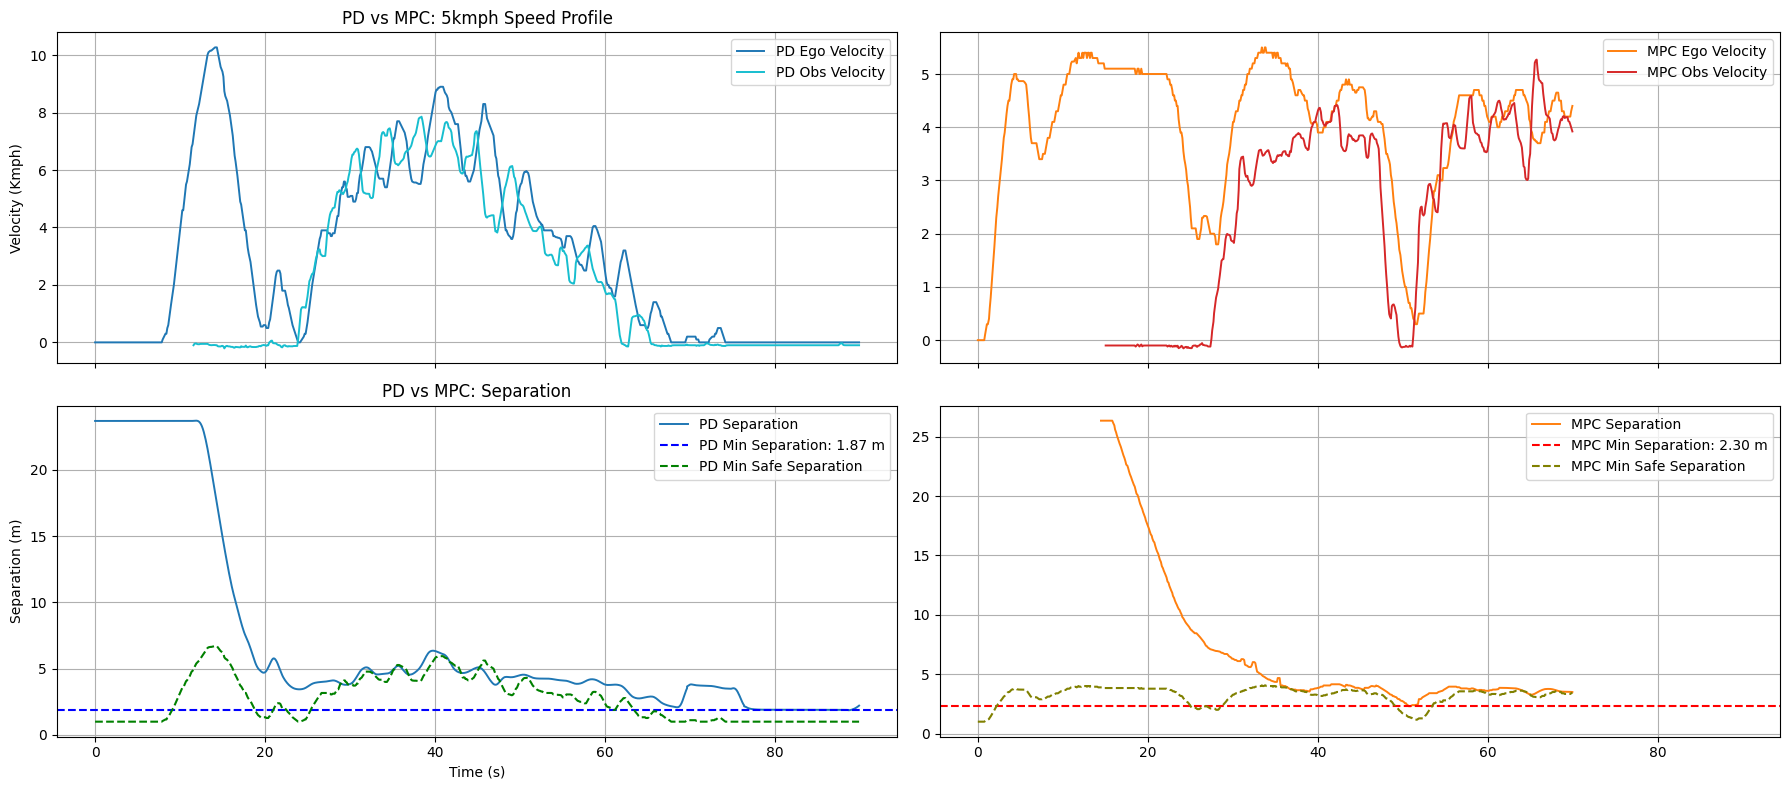

In [137]:
# Plotting the data from the selected file name for both PDC and MPC
# Assuming PDC_data_list and MPC_data_list are loaded, and PDC_file_name & MPC_file_name are selected

pdc_df = pd.read_csv(os.path.join(internal_PDC_FV_data_dir, PDC_file_name))
mpc_df = pd.read_csv(os.path.join(internal_MPC_FV_data_dir_1, MPC_file_name_5kmph))

print("PDC columns:", pdc_df.columns.tolist())
print("MPC columns:", mpc_df.columns.tolist())

# Use actual column names from your data
x_col = "Time(s)"  # Time in seconds
ego_vel_col = "Ego_Velocity_clean"
obs_vel_col = "Obs_Velocity_clean"
sep_col = "Separation_clean"

# Calculation minimum separation for both PD and MPC to plot as horizontal lines
minimum_separation_pd = pdc_df[sep_col].min()
minimum_separation_mpc = mpc_df[sep_col].min()

fig, ax = plt.subplots(2, 2, figsize=(18, 8), sharex=True)

# Plot 1: Ego velocity and obstacle velocity for PD and MPC
ax[0][0].plot(pdc_df[x_col], pdc_df[ego_vel_col], label="PD Ego Velocity", color="tab:blue", linewidth=1.4)
ax[0][0].plot(pdc_df[x_col], pdc_df[obs_vel_col], label="PD Obs Velocity", color="tab:cyan", linewidth=1.4)
ax[0][1].plot(mpc_df[x_col], mpc_df[ego_vel_col], label="MPC Ego Velocity", color="tab:orange", linewidth=1.4)
ax[0][1].plot(mpc_df[x_col], mpc_df[obs_vel_col], label="MPC Obs Velocity", color="tab:red", linewidth=1.4)
ax[0][0].set_ylabel("Velocity (Kmph)")
ax[0][0].legend(loc="best")
ax[0][1].legend(loc="best")
ax[0][0].grid(True)
ax[0][1].grid(True)
ax[0][0].set_title("PD vs MPC: 5kmph Speed Profile")

# Plot 2: Separation for PD and MPC
ax[1][0].plot(pdc_df[x_col], pdc_df[sep_col], label="PD Separation", color="tab:blue", linewidth=1.4)
ax[1][1].plot(mpc_df[x_col], mpc_df[sep_col], label="MPC Separation", color="tab:orange", linewidth=1.4)
ax[1][0].axhline(y=minimum_separation_pd, color='b', linestyle='--', label=f'PD Min Separation: {minimum_separation_pd:.2f} m')
ax[1][1].axhline(y=minimum_separation_mpc, color='red', linestyle='--', label=f'MPC Min Separation: {minimum_separation_mpc:.2f} m')
ax[1][0].set_ylabel("Separation (m)")
ax[1][0].set_xlabel("Time (s)")
ax[1][0].legend(loc="best")
ax[1][1].legend(loc="best")
ax[1][0].grid(True)
ax[1][1].grid(True)
ax[1][0].set_title("PD vs MPC: Separation")

# Minimum safe separation line ( 2 seconds at current speed + min safe distance)
min_safe_sep_pd = pdc_df["Ego_Velocity_clean"] * (1000/3600) * 2 + CP.Dd
min_safe_sep_mpc = mpc_df["Ego_Velocity_clean"] * (1000/3600) * 2 + CP.Dd
ax[1][0].plot(pdc_df["Time(s)"], min_safe_sep_pd, color="green", linestyle="--", label="PD Min Safe Separation")
ax[1][1].plot(mpc_df["Time(s)"], min_safe_sep_mpc, color="olive", linestyle="--", label="MPC Min Safe Separation")
ax[1][0].legend(loc="best")
ax[1][1].legend(loc="best")


plt.tight_layout()
plt.show() 

In [138]:
# Selecting the file name for both PDC and MPC to plot them together.
PDC_file_name = os.listdir(internal_PDC_FV_data_dir)[0]    
MPC_file_name_10kmph = os.listdir(internal_MPC_FV_data_dir_2)[0]
print(f'Selected PDC file name : {PDC_file_name}')
print(f'Selected MPC 10kmph file name : {MPC_file_name_10kmph}')

Selected PDC file name : Data_Apr9_PD_10kph_FV1.csv
Selected MPC 10kmph file name : Data_Apr7_MPC_10kph_FV2.csv


PDC columns: ['Ego_Position(m)', 'Ego_Velocity(m/s)', 'Obs_Position(m)', 'Obs_Velocity(m/s)', 'Separation(m)', 'Relative velocity(m/s)', 'Time(s)', 'Time', 'Ego_Velocity_kmph', 'Obs_Velocity_kmph', 'Ego_Velocity_clean', 'Obs_Velocity_clean', 'Separation_clean', 'Ego_Position_clean', 'Obs_Position_clean']
MPC columns: ['Ego_Position(m)', 'Ego_Velocity(m/s)', 'Obs_Position(m)', 'Obs_Velocity(m/s)', 'Separation(m)', 'Relative velocity(m/s)', 'Time(s)', 'Throttle_command', 'Time', 'Ego_Velocity_kmph', 'Obs_Velocity_kmph', 'Ego_Velocity_clean', 'Obs_Velocity_clean', 'Separation_clean', 'Ego_Position_clean', 'Obs_Position_clean']


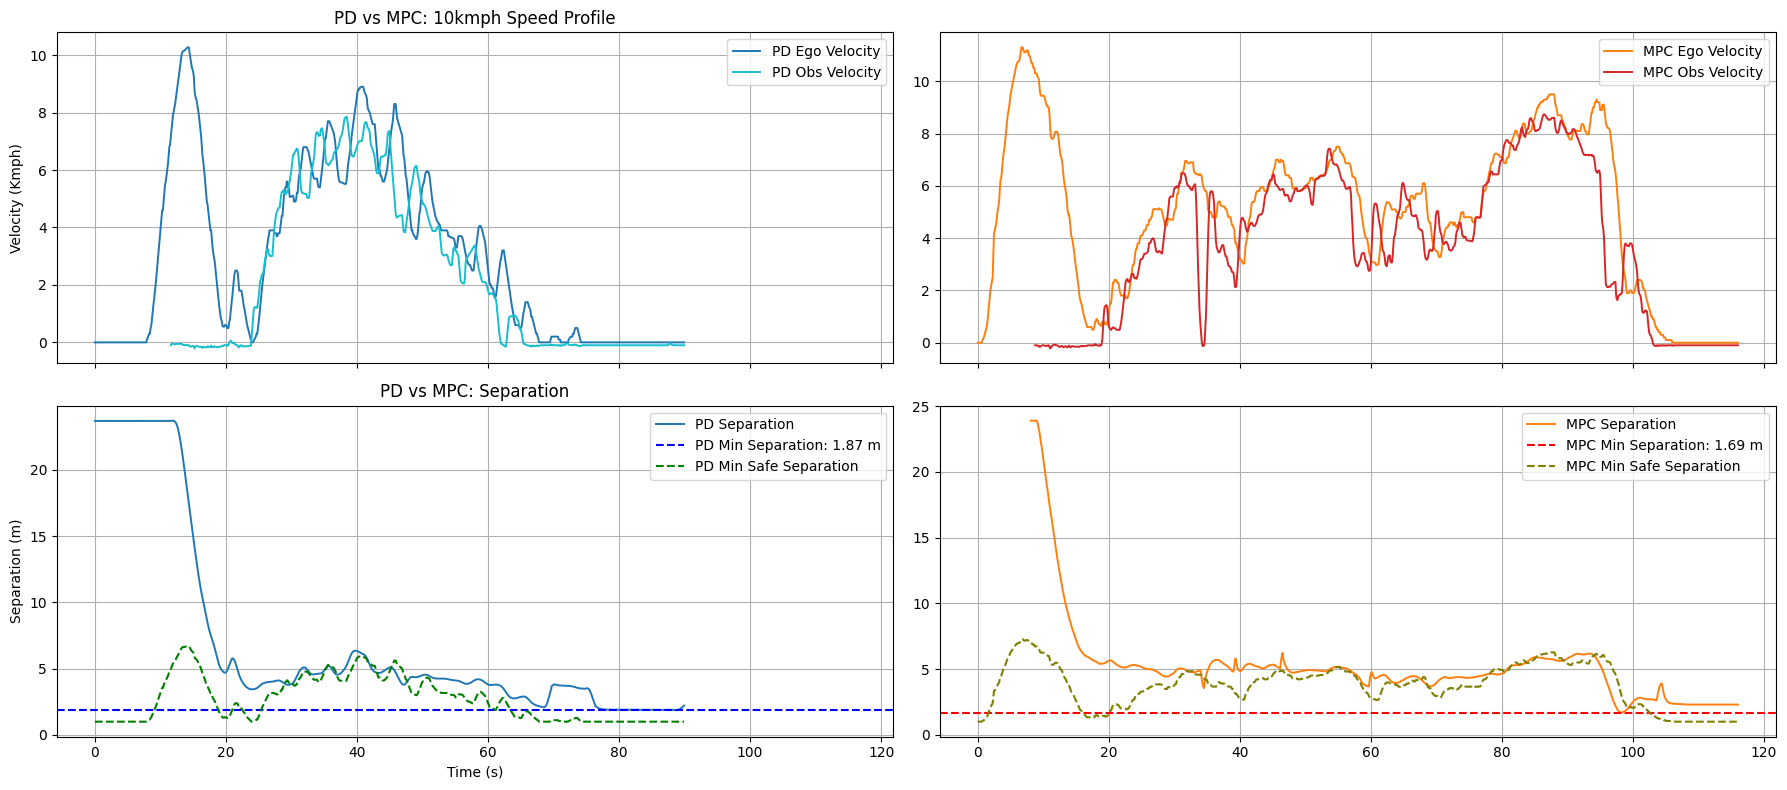

In [139]:
# Plotting the data from the selected file name for both PDC and MPC
# Assuming PDC_data_list and MPC_data_list are loaded, and PDC_file_name & MPC_file_name are selected

pdc_df = pd.read_csv(os.path.join(internal_PDC_FV_data_dir, PDC_file_name))
mpc_df = pd.read_csv(os.path.join(internal_MPC_FV_data_dir_2, MPC_file_name_10kmph))

print("PDC columns:", pdc_df.columns.tolist())
print("MPC columns:", mpc_df.columns.tolist())

# Use actual column names from your data
x_col = "Time(s)"  # Time in seconds
ego_vel_col = "Ego_Velocity_clean"
obs_vel_col = "Obs_Velocity_clean"
sep_col = "Separation_clean"

# Calculation minimum separation for both PD and MPC to plot as horizontal lines
minimum_separation_pd = pdc_df[sep_col].min()
minimum_separation_mpc = mpc_df[sep_col].min()

fig, ax = plt.subplots(2, 2, figsize=(18, 8), sharex=True)

# Plot 1: Ego velocity and obstacle velocity for PD and MPC
ax[0][0].plot(pdc_df[x_col], pdc_df[ego_vel_col], label="PD Ego Velocity", color="tab:blue", linewidth=1.4)
ax[0][0].plot(pdc_df[x_col], pdc_df[obs_vel_col], label="PD Obs Velocity", color="tab:cyan", linewidth=1.4)
ax[0][1].plot(mpc_df[x_col], mpc_df[ego_vel_col], label="MPC Ego Velocity", color="tab:orange", linewidth=1.4)
ax[0][1].plot(mpc_df[x_col], mpc_df[obs_vel_col], label="MPC Obs Velocity", color="tab:red", linewidth=1.4)
ax[0][0].set_ylabel("Velocity (Kmph)")
ax[0][0].legend(loc="best")
ax[0][1].legend(loc="best")
ax[0][0].grid(True)
ax[0][1].grid(True)
ax[0][0].set_title("PD vs MPC: 10kmph Speed Profile")

# Plot 2: Separation for PD and MPC
ax[1][0].plot(pdc_df[x_col], pdc_df[sep_col], label="PD Separation", color="tab:blue", linewidth=1.4)
ax[1][1].plot(mpc_df[x_col], mpc_df[sep_col], label="MPC Separation", color="tab:orange", linewidth=1.4)
ax[1][0].axhline(y=minimum_separation_pd, color='b', linestyle='--', label=f'PD Min Separation: {minimum_separation_pd:.2f} m')
ax[1][1].axhline(y=minimum_separation_mpc, color='red', linestyle='--', label=f'MPC Min Separation: {minimum_separation_mpc:.2f} m')
ax[1][0].set_ylabel("Separation (m)")
ax[1][0].set_xlabel("Time (s)")
ax[1][0].legend(loc="best")
ax[1][1].legend(loc="best")
ax[1][0].grid(True)
ax[1][1].grid(True)
ax[1][0].set_title("PD vs MPC: Separation")

# Minimum safe separation line ( 2 seconds at current speed + min safe distance)
min_safe_sep_pd = pdc_df["Ego_Velocity_clean"] * (1000/3600) * 2 + CP.Dd
min_safe_sep_mpc = mpc_df["Ego_Velocity_clean"] * (1000/3600) * 2 + CP.Dd
ax[1][0].plot(pdc_df["Time(s)"], min_safe_sep_pd, color="green", linestyle="--", label="PD Min Safe Separation")
ax[1][1].plot(mpc_df["Time(s)"], min_safe_sep_mpc, color="olive", linestyle="--", label="MPC Min Safe Separation")
ax[1][0].legend(loc="best")
ax[1][1].legend(loc="best")


plt.tight_layout()
plt.show() 